In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
df = pd.read_csv(r"D:\Arati\netflix_titles.csv")


In [3]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [4]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Not Available', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

C:\Users\Arati\AppData\Local\Temp\ipykernel_1520\2719582369.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
C:\Users\Arati\AppData\Local\Temp\ipykernel_1520\2719582369.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

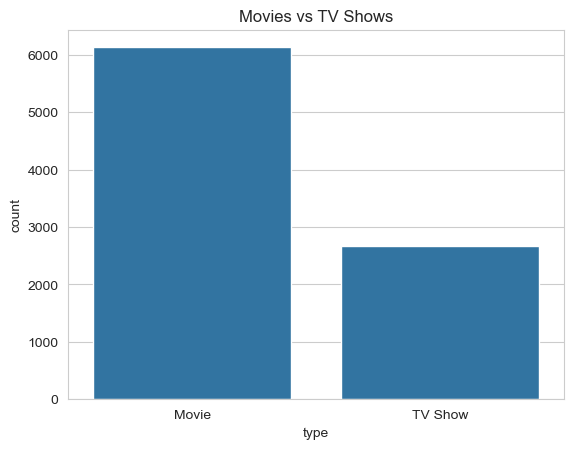

In [8]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

In [9]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

df['year_added'] = df['date_added'].dt.year

In [10]:
print(df['date_added'].isnull().sum())

98


In [11]:
df = df.dropna(subset=['date_added'])

In [12]:
df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

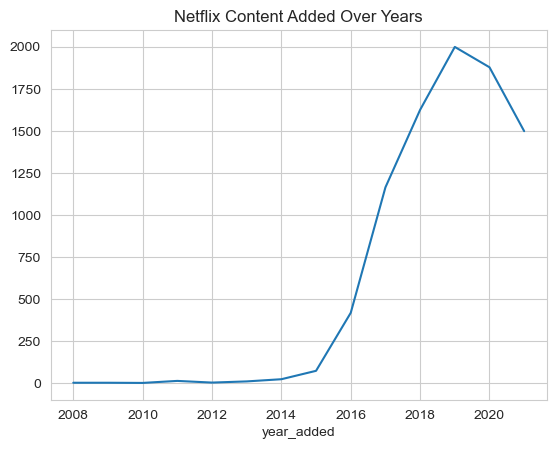

In [13]:
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Netflix Content Added Over Years")
plt.show()

In [14]:
top_country = df['country'].value_counts().head(10)

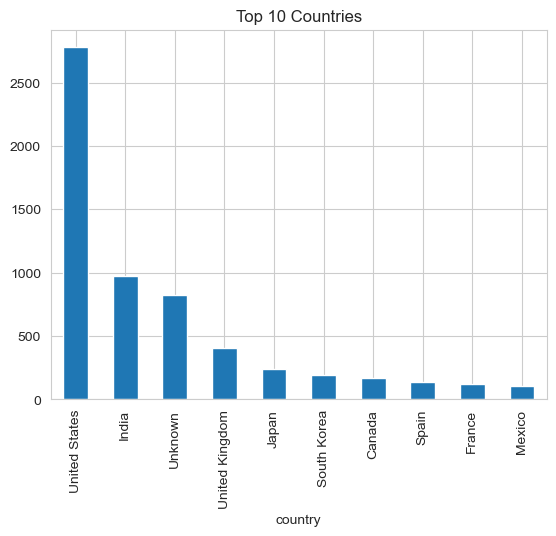

In [15]:
top_country.plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

In [16]:
df['rating'].value_counts()

rating
TV-MA       3187
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
TV-Y7-FV       5
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

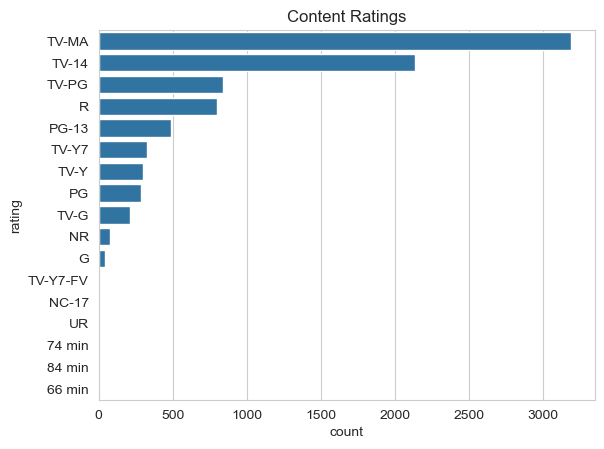

In [17]:
sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index)
plt.title("Content Ratings")
plt.show()

In [18]:
genres = df['listed_in'].str.split(', ').explode()
genres.value_counts().head(10)


listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1328
Documentaries                869
Action & Adventure           859
Independent Movies           756
TV Dramas                    739
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

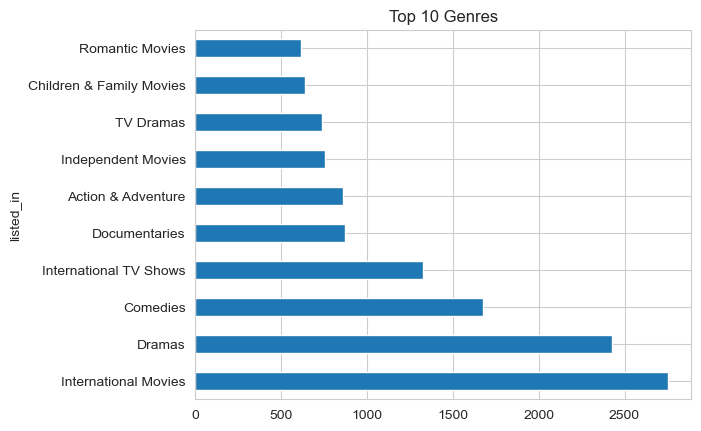

In [19]:
genres.value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Genres")
plt.show()

In [25]:
print(movies['duration'].head(10))

0      90
6      91
7     125
9     104
12    127
13     91
16     67
18     94
22    161
23     61
Name: duration, dtype: object


In [ ]:
print(movies['duration'].head())
print(movies['duration'].dtype)

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(movies['duration'], bins=30)
plt.title("Movie Duration Distribution")
plt.show()

In [ ]:
num_df = movies[['release_year','duration']]

In [ ]:
sns.heatmap(num_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [27]:
plt.savefig("top_countries.png")



<Figure size 640x480 with 0 Axes>